<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/Autoencoder_sample_CMPT419.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook uses [PyTorch](https://pytorch.org/), which is a library that can automatically differentiate functions and is commonly used to implement neural networks. Because of its capability to automatically differentiate functions, the formula for the gradient does not need to be manually derived -- this comes especially handy when working with neural networks, whose gradient formula can be quite complicated, especially for complex architectures.

We recommend going over the [PyTorch tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html) and then the starter code below. For any new functions that you come across, you can look up the documentation [here](https://pytorch.org/docs/stable/index.html).

We recommend running this notebook on Google Colab to avoid having to install PyTorch and to take advantage of GPUs, which make training faster.

## Load packages

In [17]:
# load packages, you may need to setup your environment first.
# make sure to install the pacakge "tqdm" for the progress bar when training.
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision.utils import save_image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import imageio
import matplotlib.image as mpimg
from scipy import ndimage
import cv2
from sklearn.model_selection import train_test_split

path_prefix = ""
print("Finish!")

Finish!


If running on Google Colab, you need to upload the file `autoencoder_starter.py`. To do so, you need to click on the folder icon on the left side of the page, which brings up a panel that would allow you to upload files. Note however uploading the file this way has a downside in that if your Python runtime times out or is otherwise restarted, the file will be erased and you will need to re-upload.

If you would like to avoid this, you can create a directory named `CMPT_419_2025` in your Google Drive and upload `autoencoder_starter.py` to that directory. Then execute the following block of code to mount your Google Drive.

In [18]:
from google.colab import drive
import sys

# Mount Google Drive
drive.mount('/content/drive')

# Define the file path
file_path = "/content/drive/My Drive/CMPT_419_2025/autoencoder_starter.py"

# Add the directory to the system path
sys.path.append("/content/drive/My Drive/CMPT_419_2025")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading CMPT 419 American Sign Language Dataset

# Load Dataset:

In [19]:
# load data from .npy file
# Load the provided dataset
ASL_dataset = np.load("/content/drive/My Drive/CMPT_419_2025/CMPT419_ASL_dataset.npy", allow_pickle=True)
print(f"Total number of samples: {len(ASL_dataset)}")
print(f"Each sample is a paired 128*128 raw image and the corresponding 3D coordinates for 21 hand landmakrs,  shape: {ASL_dataset[0].shape}")
print(f"Image is the first item, shape: {ASL_dataset[0][0].shape}")
print(f"Hand landmarks is the second item, shape {ASL_dataset[0][1].shape}")

Total number of samples: 6132
Each sample is a paired 128*128 raw image and the corresponding 3D coordinates for 21 hand landmakrs,  shape: (2,)
Image is the first item, shape: (128, 128, 3)
Hand landmarks is the second item, shape (21, 3)


# Visualization
We provide visualization function to inspect the data.
- `plt.imshow`: for 2D raw images
- `plot_3d_hand_landmarks`: 3D hand landmarks visualization
- `draw_landmarks_on_image`: 2D image plots with hand landmarks annotation.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 23.1 MB/s eta 0:00:00


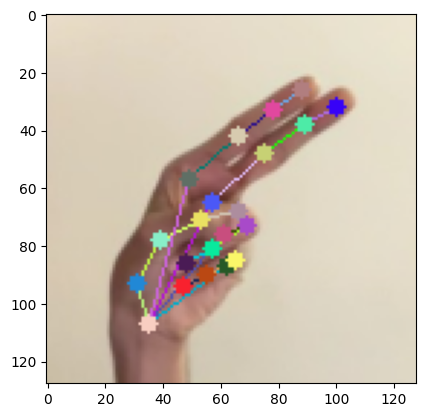

In [25]:
# visualize samples
!pip install mediapipe
from autoencoder_starter import plot_3d_hand_landmarks, draw_landmarks_on_image

sample_id = 48
sample_image = ASL_dataset[sample_id][0]
sample_landmarks = ASL_dataset[sample_id][1]

plt.imshow(sample_image)

plot_3d_hand_landmarks(sample_landmarks)

annotated_image = draw_landmarks_on_image(sample_image, sample_landmarks)
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

# Prepare Data Loader
Here we preprocess the data to be efficient for training a neural network and create Pytorch DataLoader.

In [27]:

# Initialize lists for images, landmarks, and labels
image_data = []
landmark_data = []


# Process each entry in the dataset
for image, landmarks in ASL_dataset:

    # # Convert image to grayscale and resize to 28×28
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image_resized = cv2.resize(image, (28, 28))  # Resize to 28x28
    image_normalized = image_resized / 255.0  # Normalize pixel values

    # Append processed data
    image_data.append(image_normalized)
    landmark_data.append(landmarks)


# Convert lists to NumPy arrays
image_data = np.array(image_data)
landmarks_data = np.array(landmark_data)


# ----------------------Your action is required-------------------------
# Pick one of the following Image / Landmarks data by comment and uncomment
x_data = image_data
# x_data = landmarks_data



# Split into train and validation sets (80% train, 20% validation)
x_train, x_valid = train_test_split(
    x_data, test_size=0.2, random_state=42)
print(f"Train set: {x_train.shape}")
print(f"Validation set: {x_valid.shape}")


# Convert x_train and y_train to tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)  # Ensure float32
x_valid_tensor = torch.tensor(x_valid, dtype=torch.float32)

train_loader = torch.utils.data.DataLoader(x_train_tensor, batch_size=32, shuffle=False, num_workers=4)
val_loader = torch.utils.data.DataLoader(x_valid_tensor, batch_size=32, shuffle=False, num_workers=4)

Train set: (4905, 28, 28)
Validation set: (1227, 28, 28)


## Define your architecture here.

The `Autoencoder` class has several important functions unimplemented. You are required to implement the two sub-classes of `Encoder` and `Decoder`, i.e, the architecture and forward function of the encoder and decoder.


In [ ]:
class Autoencoder(nn.Module):

    def __init__(self,dim_latent_representation=2):

        super(Autoencoder,self).__init__()

        class Encoder(nn.Module):
            def __init__(self, latent_dim=2):
                super(Encoder, self).__init__()

                # Needs your implementation
                self.nn = ...


            def forward(self, x):
                return self.nn(x)


        class Decoder(nn.Module):
            def __init__(self, latent_dim=2):
                super(Decoder, self).__init__()

                # Needs your implementation
                self.nn = ...


            def forward(self, z):
                return self.nn(z)


        self.encoder = Encoder(latent_dim=dim_latent_representation)
        self.decoder = Decoder(latent_dim=dim_latent_representation)


    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## Training the Model

The training loop is provided by the `Autoencoder_Trainer` class from `autoencoder_starter.py`.

In [ ]:
%load_ext autoreload
%autoreload 2

from autoencoder_starter import Autoencoder_Trainer

# the number of epochs and learning rate can be tuned.
LEARNING_RATE = 1e-3
EPOCH_NUMBER= 20
rep_dim = 2



autoencoder = Autoencoder(dim_latent_representation=rep_dim)
trainer = Autoencoder_Trainer(autoencoder, train_loader, val_loader, LEARNING_RATE)


print(autoencoder)
for epoch in range(1, EPOCH_NUMBER + 1):
    trainer.train(epoch)
    trainer.validate(epoch)
print('Training is finished!')

## Visualizing Bottleneck Feature Representations

We can visualize the bottleneck representations of data points with a 2D scatter plot.

The `scatter_plot` function takes the following arguments:
* latent_presentations - (N, dimension_latent_representation) numpy array
* labels - (N, ) numpy array: the labels of predicted cluster or None

In [ ]:
with torch.no_grad():
    model = trainer.model
    model.eval()
    z=[];label=[]

    for x in trainer.val_loader:
        x = x.view(x.size(0),-1)
        z_ = model.encoder(x.to(trainer.device))
        z += z_.cpu().tolist()
    z = np.asarray(z)


from autoencoder_starter import scatter_plot
scatter_plot(latent_representations=z,labels=None) # You can use your cluster labels heere.


## Find the optimum number of clusters
### Elbow Evaluation

In [ ]:
# Needs your implementation

### Silhouette score analysis

In [ ]:
# Needs your implementation

## Cluster and visualize
Use your best geuss of number of clusters and visualize the 2D scatter plot of the latent variables colored regarding their predicted label

In [ ]:
# Needs your implementation


## Reconstructing Images

We can first retrieve the validation set and then pick 64 images (the first 64 images, though you can do it randomly).

We use the autoencoder to reconstruct the images and visualize them below.

In [ ]:
images = trainer.get_val_set() # get the entire validation set
total_number = 64
print(images.shape)
images = images[:total_number]

from autoencoder_starter import display_images_in_a_row
print("Original images")
display_images_in_a_row(images.cpu())

### Image reconstruction
Load samples and reconstruct it using trained network.

In [ ]:
# Reconstruction

with torch.no_grad():
    images = images.to(trainer.device)
    images = images.view(images.size(0), -1)
    reconstructed = trainer.model(images)
    reconstructed = reconstructed.cpu()
print("Reconstructed images")
display_images_in_a_row(reconstructed)

### Hand reconstruction
We can retrieve the validation set and then pick one sample to reconstruct on visualuze using trained `autoencoder`.

In [ ]:
landmarks = trainer.get_val_set() # get the entire validation set
total_number = 32
print(images.shape)
# landmarks = images[:total_number]
sample_landmarks = landmarks[1]
from autoencoder_starter import display_images_in_a_row
print("Original images")
plot_3d_hand_landmarks(sample_landmarks)

In [ ]:
# Reconstruction

with torch.no_grad():
    sample_landmarks = sample_landmarks.to(trainer.device)
    sample_landmarks = sample_landmarks.unsqueeze(0) # batchifying
    print(sample_landmarks.shape)
    sample_landmarks = sample_landmarks.view(sample_landmarks.size(0), -1) #1, 28, 28) # -1)
    print(sample_landmarks.shape)
    reconstructed = trainer.model(sample_landmarks)
    reconstructed = reconstructed.cpu().view(reconstructed.size(0), 21, 3)
    reconstructed = reconstructed.squeeze()
print("Reconstructed Hand landmarks")
plot_3d_hand_landmarks(reconstructed)